# Machine Forgetters CS5841 Final Project Code File
Connor Donahue, Connor Fleser, Jessica Feliz Garrido, and Matthew Harrelson

## **Imports**: import packages used in the notebook

In [438]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random

## **Load Data**: load data used to construct model

In [439]:
# read in feature data from two csv files
df1 = pd.read_csv("pure_spectra_matrix.csv", sep=";", header = None, decimal =".")
df2 = pd.read_csv("mixed_spectra_matrix.csv", sep=";", header = None, decimal =".")

# read in label data from label files
labels1 = pd.read_csv("pure_spectra_metadata.csv", sep=";")["Species"]

# for second pair of feature and label file, pure spectra must be separated from mixed spectra 
temp_labels2 =  pd.read_csv("mixed_spectra_metadata.csv", sep=";")
labels2 = temp_labels2[(temp_labels2['Proportion'] == 0) | (temp_labels2['Proportion'] == 1)]  
df2 = df2[(temp_labels2['Proportion'] == 0) | (temp_labels2['Proportion'] == 1)]

# store labels for pure spectra
species = []
for i in range(labels2.shape[0]):
    if (labels2['Proportion'].iloc[i] == 0):
        species.append(labels2["Species_2"].iloc[i])
    else: 
        species.append(labels2["Species_1"].iloc[i])

labels2 = pd.Series(species)

# combine two data sets into one dataframe
df = pd.concat([df1, df2])
labels = pd.concat([labels1, labels2])

# visualize first few entries in the dataframe
df.head()

,0,1,2,3,4,5,6,7,8,9,...,1290,1291,1292,1293,1294,1295,1296,1297,1298,1299
0,0,0.0,0.0,0.0,0.0,0,44431.921875,0.0,0.0,0.0,...,0.000000,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.0,...,27667.777344,0.0,0,0.0,35438.351562,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.0,...,59820.968750,0.0,0,0.0,6384.590820,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0.0,0.0,0.0,0,4701.712402,0.0,0.0,0.0,...,3913.969727,0.0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


## **Preprocessing and Splitting Data**

### Global Variables and Random Seeds

In [440]:
BATCH = 32
EPOCHS = 50
HE = tf.keras.initializers.HeNormal(seed=42)
random.seed(42)
tf.random.set_seed(42)

### Training and Testing Spit

In [441]:
# training and testing split (10% test, 10% validation, 80% training)
X_trainval, X_test, y_trainval, y_test = train_test_split(df, labels, test_size = 0.1, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.11, stratify = y_trainval)

# encode categorical labels  
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

# display dimensions of training, validation, and test data
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(520, 1300)
(65, 1300)
(66, 1300)


### Preprocessing and Batching

(32, 1300, 1) (32,)
range: tf.Tensor(0.0, shape=(), dtype=float32) - tf.Tensor(28.260246, shape=(), dtype=float32)


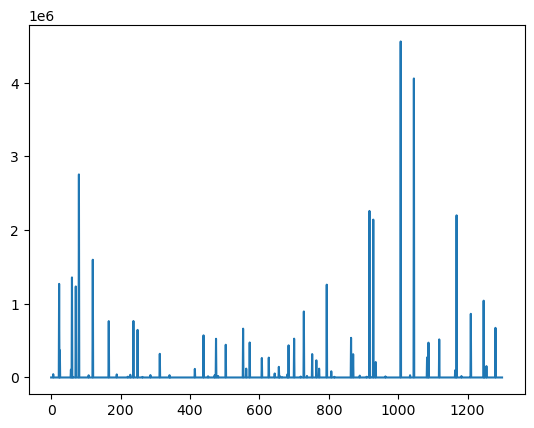

In [442]:
# define helper functions for preprocessing data

def preprocess(x, y):
  x = tf.math.log1p(x)
  x = tf.expand_dims(x, axis=-1)
  return x, y

def getTrainData():
  return tf.data.Dataset.from_tensor_slices((X_train, y_train)).map(preprocess,BATCH).map(augment,BATCH).shuffle(buffer_size=64).batch(BATCH).prefetch(tf.data.AUTOTUNE)

def getValData():
  return tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(preprocess,BATCH).batch(BATCH).prefetch(tf.data.AUTOTUNE)

def getTestData():
  return tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(preprocess,BATCH).batch(BATCH).prefetch(tf.data.AUTOTUNE)

img, label = next(iter(getTrainData()))
print(img.shape, label.shape)
print("range: " + str(tf.reduce_min(img)) + " - " + str(tf.reduce_max(img)))


plt.plot(df.iloc[0])
plt.show()


## Model Construction and Training

### Model 1: Feed-Forward Neural Network

In [443]:
# input layer with batch normalization
inputs = layers.Input(shape=(X_train.shape[1],))
x = layers.BatchNormalization()(inputs)

# dense layer with dropout, leaky relu activation, and batch normalization
x = layers.Dense(1024, kernel_initializer=HE)(x)
x = layers.Dropout(0.2)(x)
x = layers.LeakyReLU(alpha=0.2)(x)
x = layers.BatchNormalization()(x)

# dense layer with dropout, leaky relu activation, and batch normalization
x = layers.Dense(128, activation="relu", kernel_initializer=HE)(x)
x = layers.Dropout(0.2)(x)
x = layers.LeakyReLU(alpha=0.2)(x)
x = layers.BatchNormalization()(x)

# softmax output layer
outputs = layers.Dense(num_classes, activation="softmax")(x)

# store model
ffn = tf.keras.Model(inputs=inputs, outputs=outputs, name="basicFeedforward")

# compile model with Adam optimizer and sparse categorical cross-entropy loss 
ffn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# ouput summary of model structure 
ffn.summary()

# create callback for optimal training 
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,         
    verbose=1,          
    restore_best_weights=True 
)

# fit model to training data
ffn_hist = ffn.fit(
    getTrainData(),
    validation_data = getTestData(),
    epochs = EPOCHS,
    callbacks = callback
)

# print best validation accuracy achieved during training
best_acc = float(np.max(ffn_hist.history["val_accuracy"]))
print("Best validation accuracy: " + str(best_acc))

Model: "basicFeedforward"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_128 (InputLayer)      [(None, 1300)]            0         
                                                                 
 batch_normalization_258 (B  (None, 1300)              5200      
 atchNormalization)                                              
                                                                 
 dense_289 (Dense)           (None, 1024)              1332224   
                                                                 
 dropout_114 (Dropout)       (None, 1024)              0         
                                                                 
 leaky_re_lu_122 (LeakyReLU  (None, 1024)              0         
 )                                                               
                                                                 
 batch_normalization_259 (B  (None, 1024)         

### Model 2: 1-Dimensional Convolutional Neural Network

In [444]:
# input layer with batch normalization
inputs = layers.Input(shape=(X_train.shape[1],))   
x = layers.BatchNormalization()(x)
# expand input to 3 dimensions for convolution layer
x = tf.expand_dims(inputs, axis=-1)

x = layers.Conv1D(32, 32, activation='relu', input_shape=x.shape)(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(32, 64, activation='relu')(x)
x = layers.MaxPooling1D(2)(x)

# Flatten and Classify
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)



# store model
cnn = tf.keras.Model(inputs, outputs)

# output summary of model structure
cnn.summary()

# compile model with adam optimizer and sparse categorical cross-entropy loss
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# create callback for optimal training 
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,         
    verbose=1,          
    restore_best_weights=True 
)

# fit model to training data 
cnn_hist = cnn.fit(
    getTrainData(),
    validation_data = getValData(),
    epochs = EPOCHS,
    callbacks= callback
)

# output best validation accuracy during training
best_acc = float(np.max(cnn_hist.history["val_accuracy"]))
print("Best validation accuracy: " + str(best_acc))


Model: "model_64"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_129 (InputLayer)      [(None, 1300)]            0         
                                                                 
 tf.expand_dims_61 (TFOpLam  (None, 1300, 1)           0         
 bda)                                                            
                                                                 
 conv1d_54 (Conv1D)          (None, 1269, 32)          1056      
                                                                 
 max_pooling1d_25 (MaxPooli  (None, 634, 32)           0         
 ng1D)                                                           
                                                                 
 conv1d_55 (Conv1D)          (None, 571, 32)           65568     
                                                                 
 max_pooling1d_26 (MaxPooli  (None, 285, 32)           0  

### Model 3: Attention-Based Model

In [445]:
# input layer with batch normalization
inputs = layers.Input(shape=(X_train.shape[1],))   
x = layers.BatchNormalization()(x)
# expand input to 3 dimensions for attention layer
x = tf.expand_dims(inputs, axis=1)

# store inputs for residual connection
shortcut = x

# 8-head attention layer
x = layers.MultiHeadAttention(num_heads=8, key_dim=8)(x, x)

# residual connection and batch normalization 
x = layers.Add()([x, shortcut])
x = layers.BatchNormalization()(x)

# dense layer with leaky relu activation, dropout, and batch normalization
x = layers.Dense(256, kernel_initializer=HE)(x)
x = layers.Dropout(0.2)(x)
x = layers.LeakyReLU(alpha=0.2)(x)
x = layers.BatchNormalization()(x)

# flatten data back to 2 dimensions and apply softmax activation layer
x = layers.Flatten()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

# store model
att = tf.keras.Model(inputs, outputs)

# output summary of model structure
att.summary()

# compile model with adam optimizer and sparse categorical cross-entropy loss
att.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# create callback for optimal training 
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,         
    verbose=1,          
    restore_best_weights=True 
)

# fit model to training data 
att_hist = att.fit(
    getTrainData(),
    validation_data = getValData(),
    epochs = EPOCHS,
    callbacks = callback
)

# output best validation accuracy during training
best_acc = float(np.max(att_hist.history["val_accuracy"]))
print("Best validation accuracy: " + str(best_acc))

Model: "model_65"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_130 (InputLayer)      [(None, 1300)]               0         []                            
                                                                                                  
 tf.expand_dims_62 (TFOpLam  (None, 1, 1300)              0         ['input_130[0][0]']           
 bda)                                                                                             
                                                                                                  
 multi_head_attention_62 (M  (None, 1, 1300)              334292    ['tf.expand_dims_62[0][0]',   
 ultiHeadAttention)                                                  'tf.expand_dims_62[0][0]']   
                                                                                           

## Model Evaluation

In [446]:
ffn_loss, ffn_acc = ffn.evaluate(getTestData())
print(ffn_acc)

cnn_loss, cnn_acc = cnn.evaluate(getTestData())
print(cnn_acc)

att_loss, att_acc = att.evaluate(getTestData())
print(att_acc)

3/3 [==============================] - 0s 6ms/step - loss: 0.0663 - accuracy: 0.9697
0.9696969985961914
3/3 [==============================] - 0s 11ms/step - loss: 0.2531 - accuracy: 0.9242
0.9242424368858337
3/3 [==============================] - 0s 6ms/step - loss: 0.0681 - accuracy: 0.9848
0.9848484992980957
